[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Projects/project_6_fund/project_6_starter.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Project 6 — How many of these managers can actually pick stocks?

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Data:** `Fund.csv` — 50 months of excess returns for 2,000 fund managers  
**Methods:** Chapter 13 (multiple testing) with Chapter 0 §7 (hypothesis tests) · **After:** Lecture 12 · **Time:** 3–5 hours

**Goal.** A pension trustee holds an adviser's shortlist of fund managers with "statistically significant outperformance" and is about to allocate real money against it. You must hand back **one number**: how many of these 2,000 managers can be identified, on this evidence, as genuinely skilled. The number may be **zero**, and if it is, the memo has to say so and say why that is the honest answer rather than a failure of the analysis.

This notebook loads the data, states the one fact that governs the whole problem, seals a held-out window of months, computes the two baselines you have to beat, and gives you the single evaluation helper that makes your number comparable with everyone else's. Your work begins at **Step 1**.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.

> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


In [2]:
# Everything this project needs beyond the setup cell.
from scipy.stats import ttest_1samp                    # the test, applied down each column
from statsmodels.stats.multitest import multipletests  # Bonferroni / Holm / Benjamini-Hochberg

pd.set_option('display.width', 110)
print('ready')

ready


## 1. The data

`Fund.csv` holds the **monthly excess return** of each of 2,000 fund managers over the same 50 months. An *excess* return is already net of the benchmark: a manager who exactly tracked their benchmark records zero. So the question "does this manager have skill?" is the question "is the mean of this column different from zero?" — a one-sample $t$-test, Chapter 0 §7.

Note the orientation: **rows are months, columns are managers.** The first column of the CSV is the month label, so it becomes the index rather than a variable — but the ISLP package numbers the same 50 months from 0 where the CSV numbers them from 1, so the cell below re-labels the rows by **position** and keeps `MONTHS` (1–50) as the only month numbering the notebook ever prints or reasons about. Select rows with `.iloc` throughout.

In [3]:
fund = load('Fund', index_col=0)        # rows = months, columns = managers

# load() returns the ISLP package's frame when ISLP is installed (as on Colab)
# and the bundled CSV otherwise; the two number the months differently
# (0-based vs 1-based). Same rows, same order -- so re-label positionally and
# speak about months 1-50 consistently everywhere.
fund = fund.reset_index(drop=True)
MONTHS = fund.index + 1                 # human-facing month numbers, 1..50

n_months, n_managers = fund.shape
print(f'{n_months} months x {n_managers} managers')
print('\nreturns are in per cent per month:')
head = fund.iloc[:4, :5].round(2)       # first four months, first five managers
head.index = MONTHS[:4]                 # label rows by month number, not by position
print(head.to_string())

50 months x 2000 managers

returns are in per cent per month:
   Manager1  Manager2  Manager3  Manager4  Manager5
1     -3.34     -4.17      9.39      8.42      1.00
2      3.76     12.53      3.40      0.14     -7.22
3     12.97     -2.58     -0.82      6.58     17.05
4     -4.87      7.98     -4.03     -4.73      0.50


### The target: 2,000 track records

There is no single response variable here. The quantity of interest is one number per manager — the average of their 50 monthly excess returns.

count    2000.000
mean       -0.030
std         1.360
min        -4.809
25%        -0.737
50%        -0.036
75%         0.681
max         4.873


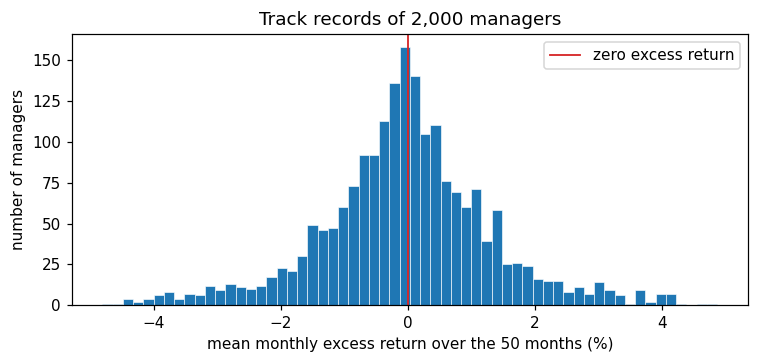

In [4]:
manager_mean = fund.mean()             # 2,000 averages, one per manager, in % per month
print(manager_mean.describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(manager_mean, bins=60, color='C0', edgecolor='white', linewidth=0.4)
ax.axvline(0.0, color='C3', lw=1.2, label='zero excess return')
ax.set(xlabel='mean monthly excess return over the 50 months (%)',
       ylabel='number of managers',
       title='Track records of 2,000 managers')
ax.legend()
plt.tight_layout(); plt.show()

### The single fact that shapes this problem

Fifty months is a **short** record against the volatility of a fund. The table below reports, for the typical manager, the monthly standard deviation of returns and the resulting standard error of their 50-month average — and then the mean return a manager would need in order for a $t$-test on their own column to reach $p < 0.05$.

Read that last number carefully before you do anything else. It sets the resolution of every conclusion in this project: it is the *smallest amount of skill this data set is physically capable of detecting in one manager.*

In [5]:
sd_monthly = fund.std()                              # per-manager volatility, % per month
se_mean    = sd_monthly / np.sqrt(n_months)          # SE of that manager's 50-month average
from scipy.stats import t as t_dist
crit = t_dist.ppf(0.975, df=n_months - 1)            # two-sided 5% critical value, df = 49

print(f'months per manager                     n = {n_months}')
print(f'median monthly volatility                  {sd_monthly.median():6.2f} % per month')
print(f'median standard error of the mean          {se_mean.median():6.2f} % per month')
print(f'two-sided 5% critical value (df={n_months-1})       {crit:6.2f}')
print(f'=> detectable at p<0.05 only if |mean| >    {crit * se_mean.median():6.2f} % per month'
      f'  ({12 * crit * se_mean.median():.1f} % per year)')
print(f'\nfor comparison, the best 50-month record in the data is '
      f'{manager_mean.max():.2f} % per month')

months per manager                     n = 50
median monthly volatility                    7.04 % per month
median standard error of the mean            1.00 % per month
two-sided 5% critical value (df=49)         2.01
=> detectable at p<0.05 only if |mean| >      2.00 % per month  (24.0 % per year)

for comparison, the best 50-month record in the data is 4.87 % per month


### The number of tests

The second governing fact is arithmetic: you are about to run **2,000** hypothesis tests, not one. Chapter 13 exists because of what that does to the meaning of a $p$-value.

In [6]:
m = n_managers
print(f'number of simultaneous tests            m = {m}')
print(f'Bonferroni threshold at alpha = 0.05        {0.05 / m:.3g}')
print(f'smallest BH threshold (rank 1, q = 0.05)    {0.05 / m:.3g}')
print(f'largest  BH threshold (rank m, q = 0.05)    {0.05:.3g}')

number of simultaneous tests            m = 2000
Bonferroni threshold at alpha = 0.05        2.5e-05
smallest BH threshold (rank 1, q = 0.05)    2.5e-05
largest  BH threshold (rank m, q = 0.05)    0.05


## 2. The sealed months

The audit in Steps 1–6 uses **all 50 months**, because all 50 months are what the adviser saw and what the trustee is being asked to act on. Those steps produce counts, not a portfolio, so they cannot leak anything into what follows.

Step 7 is a different and stricter exercise. A trustee does not want to know which managers *were* good; they want to know whether a selection rule applied today survives contact with months it has never seen. So the record is split **chronologically** — you pick from the past and are marked on the future, which is the only split that means anything for a fund. The split is fixed here, identical for every student, so that every reported number is comparable.

> **The seal.** `holdout` is spent **once**, in Step 7, through `evaluate_selection()`. Any selection rule you design must be fitted on `train` alone — no thresholds tuned on the holdout, no "let me just check". The two baselines below have already been evaluated for you; that is the instructor's call on the sealed window, not yours.

In [7]:
TRAIN_MONTHS = 35                      # fixed for everyone -- do not change

train   = fund.iloc[:TRAIN_MONTHS]     # months 1-35  : your evidence window
holdout = fund.iloc[TRAIN_MONTHS:]     # months 36-50 : SEALED until Step 7

# Labels come from MONTHS (position + 1), never from the frame's own index, so
# the window prints as months 1-35 / 36-50 on every machine.
print(f'train   : months {MONTHS[0]:>2}-{MONTHS[TRAIN_MONTHS - 1]:<2} '
      f'-> {train.shape[0]} months x {train.shape[1]} managers')
print(f'holdout : months {MONTHS[TRAIN_MONTHS]:>2}-{MONTHS[-1]:<2} '
      f'-> {holdout.shape[0]} months x {holdout.shape[1]} managers')

# The quantity every selection is finally judged on: what a manager actually
# delivered, per month, over the 15 sealed months.
holdout_mean = holdout.mean()
print(f'\nholdout months carry a standard error of '
      f'{(holdout.std() / np.sqrt(len(holdout))).median():.2f} % per month for a single manager,')
print(f'so a selection of k managers is resolved to about '
      f'{(holdout.std() / np.sqrt(len(holdout))).median() / np.sqrt(146):.2f} % per month at k = 146.')

train   : months  1-35 -> 35 months x 2000 managers
holdout : months 36-50 -> 15 months x 2000 managers

holdout months carry a standard error of 1.72 % per month for a single manager,
so a selection of k managers is resolved to about 0.14 % per month at k = 146.


## 3. The two baselines you have to beat

**Baseline A — the whole population.** Allocate to all 2,000 managers, i.e. exercise no judgement at all. This is what "picking managers" has to beat to be worth paying for.

**Baseline B — the adviser's method, applied honestly.** Take the adviser's own rule — an uncorrected $t$-test at $p < 0.05$ — but fit it on the 35 training months rather than on the months it is then judged on. This is the shortlist the trustee would actually have held.

A selection rule that cannot beat Baseline B has added nothing to the adviser's work. A selection rule that cannot beat Baseline A has added nothing to *no work at all*.

In [8]:
# Baseline A: no selection.
BASELINE_A = holdout_mean.mean()

# Baseline B: the adviser's uncorrected rule, fitted on the training months only.
t_train, p_train = ttest_1samp(train, 0.0, axis=0)
adviser_rule = pd.Series(p_train < 0.05, index=fund.columns)
BASELINE_B = holdout_mean[adviser_rule].mean()

print('BASELINES (mean excess return per month over the 15 sealed months)\n')
print(f'A  all {n_managers} managers, no selection          '
      f'{BASELINE_A:+.4f} %/month')
print(f'B  adviser\'s rule p<0.05 on months 1-35     '
      f'{BASELINE_B:+.4f} %/month   (selects {int(adviser_rule.sum())} managers)')
print(f'\n   difference, B - A                        {BASELINE_B - BASELINE_A:+.4f} %/month')

BASELINES (mean excess return per month over the 15 sealed months)

A  all 2000 managers, no selection          -0.0122 %/month
B  adviser's rule p<0.05 on months 1-35     -0.0489 %/month   (selects 241 managers)

   difference, B - A                        -0.0367 %/month


### The evaluation helper

Call this **once**, in Step 7, with the managers your rule selects. It reports the holdout mean, how it compares with Baseline A, and a permutation $p$-value: the probability that a *randomly chosen* set of managers of the same size would have done at least as well. That permutation null is the right comparison, because a large selection is automatically less variable than a small one and a raw mean does not tell you which effect you are looking at.

In [9]:
def _as_mask(managers):
    """Accept either a boolean mask over fund.columns or an iterable of manager names."""
    arr = np.asarray(managers)
    if arr.dtype == bool:
        if arr.shape != (n_managers,):
            raise ValueError(f'boolean mask must have length {n_managers}, got {arr.shape}')
        return arr
    return fund.columns.isin(arr)


def evaluate_selection(managers, label='my selection', n_perm=5000, seed=2024):
    """Score a selection of managers on the sealed holdout months. Call once.

    managers : boolean mask over fund.columns, or an iterable of manager names
    """
    sel = _as_mask(managers)
    k = int(sel.sum())
    if k == 0:
        print(f'{label}: no managers selected. The honest holdout return of an empty '
              f'allocation is 0.0000 %/month, and that is a legitimate answer.')
        return {'n': 0, 'holdout_mean': 0.0, 'frac_positive': float('nan'),
                'vs_baseline_A': -BASELINE_A, 'perm_p': float('nan')}

    vals = holdout_mean[sel]
    obs  = vals.mean()
    _rng = np.random.default_rng(seed)
    null = np.array([_rng.choice(holdout_mean.values, k, replace=False).mean()
                     for _ in range(n_perm)])
    perm_p = float((null >= obs).mean())

    print(f'--- {label} ---')
    print(f'managers selected                      {k}')
    print(f'holdout mean excess return             {obs:+.4f} %/month')
    print(f'   vs Baseline A ({BASELINE_A:+.4f})            {obs - BASELINE_A:+.4f} %/month')
    print(f'   vs Baseline B ({BASELINE_B:+.4f})            {obs - BASELINE_B:+.4f} %/month')
    print(f'share with positive holdout return     {(vals > 0).mean():.3f}')
    print(f'permutation p (vs random sets of {k})   {perm_p:.4f}   [{n_perm} draws, seed {seed}]')
    return {'n': k, 'holdout_mean': float(obs), 'frac_positive': float((vals > 0).mean()),
            'vs_baseline_A': float(obs - BASELINE_A), 'perm_p': perm_p}

# Demonstration on Baseline B, so you can see the output format before you spend your one call.
_ = evaluate_selection(adviser_rule.values, label="Baseline B (adviser's rule, months 1-35)")

--- Baseline B (adviser's rule, months 1-35) ---
managers selected                      241
holdout mean excess return             -0.0489 %/month
   vs Baseline A (-0.0122)            -0.0367 %/month
   vs Baseline B (-0.0489)            +0.0000 %/month
share with positive holdout return     0.523
permutation p (vs random sets of 241)   0.6224   [5000 draws, seed 2024]


---

**Everything above is scaffolding. Your work starts here.**

## Step 1 — Reproduce the adviser's shortlist  *(Chapter 0 §7, Chapter 13)*

Run the one-sample $t$-test on **all 50 months** for every manager — `ttest_1samp(fund, 0.0, axis=0)` does all 2,000 at once and is far faster than a loop. Then count how many managers reach $p < 0.05$.

That count is the adviser's shortlist, and it is the object under audit for the rest of the project. Report it. Do not yet interpret it.

## Step 2 — What would chance alone produce?  *(Chapter 13)*

Before you decide what the shortlist means, work out what a shortlist of that kind would look like if **not one** of the 2,000 managers had any skill whatsoever — the *global null*.

1. Compute the **expected number of false positives** under the global null at $\alpha = 0.05$ with $m = 2{,}000$. This is one line of arithmetic and it is a required number in the memo.
2. Then get the same quantity empirically, which also gives you its spread. The sign-flip permutation of Chapter 13 §4 is the natural tool: multiplying a whole *month* by $-1$ destroys any true mean while preserving each manager's volatility and any correlation between managers. Re-run the 2,000 tests on a few hundred such flipped data sets and record the count of $p < 0.05$ each time.

Report the arithmetic expectation, and the permutation mean and standard deviation. Then say — in one sentence — how the adviser's count compares.

## Step 3 — Control the family-wise error rate  *(Chapter 13)*

Apply **Bonferroni** and **Holm**, both at a family-wise error rate of 0.05. Use `multipletests(..., method='bonferroni')` and `method='holm'`, or implement the thresholds by hand — the ordered comparison $p_{(j)} < \alpha/(m-j+1)$ for Holm is worth writing out once so that you know what the function is doing.

Report how many managers survive each. State in one sentence what the surviving set is a guarantee *about*: FWER control is a statement about the probability of **any** false claim in the whole family, which is a very strong thing to promise across 2,000 tests.

## Step 4 — Control the false discovery rate  *(Chapter 13)*

Apply **Benjamini–Hochberg** at $q = 0.05$ and again at $q = 0.10$. Plot the sorted $p$-values against the BH line $jq/m$ as in Chapter 13 §3 — with 2,000 points the picture tells you immediately why the two thresholds disagree as violently as they do.

Report both counts. Then confront the disagreement directly: the trustee was never told which $q$ to use, and the answer moves by more than a hundred managers depending on the choice. **Argue the choice from the consequence, not from convention.** What does it cost this trustee to fund one manager who turns out to have no skill? What does it cost them to overlook one who has? An answer that says "0.05 is standard" has not done the work.

## Step 5 — Read the survivors, do not just count them  *(Chapter 0 §7)*

The adviser's claim was **outperformance**. Your test was two-sided.

Take every set you have produced — the naive shortlist and each set of survivors — and break it down by the **sign** of the $t$-statistic. Report the breakdown as a small table. Then say what the pattern implies. This step is three lines of code and it changes the answer; do not skip it because it looks trivial.

## Step 6 — Is the global null itself tenable?  *(Chapter 13, Chapter 0 §6)*

Steps 3–5 asked *which individual managers* can be named. This step asks a different and much weaker question, and you must keep the two apart: **is it credible that none of the 2,000 has any skill at all?**

That is a single hypothesis about the population, so it is not a multiple-testing problem and it is not subject to any of the corrections above. At least two routes are open to you:

- **Dispersion.** Under the global null, the only reason the 2,000 track records differ is sampling noise, so the spread of `manager_mean` is pinned down by the per-manager standard errors you printed in §1. Compare the spread you observe with the spread the null permits.
- **Persistence.** Under the global null a manager's average over one set of months carries no information about their average over a *disjoint* set. Split the 50 months in two (odd/even months, or first 25 against last 25 — say which and why) and correlate the two averages across the 2,000 managers. Define the split by **position** — `fund.iloc[::2]` is months 1, 3, 5, …, `fund.iloc[:25]` is months 1–25 — so that the halves are the same on any machine.

Either way, sanity-check the alternative explanations before you believe the result: fat tails, unequal volatilities across managers, correlation between managers, autocorrelation within a manager. A sign-flip permutation gives you the null distribution of whichever statistic you chose, without assuming any of that away.

Report your statistic, its null reference, and one sentence on what it does and does not license you to tell the trustee.

## Step 7 — Break the seal, once  *(Chapter 5 discipline, Chapter 13)*

Design **one** selection rule using the 35 training months only. Anything is fair: a corrected procedure at whichever threshold you defended in Step 4, a sign filter, a top-$k$ rule, a shrunken estimate of each manager's mean. Fix it, write down what you expect it to deliver, *then* call `evaluate_selection()` a single time.

Report the holdout mean, the comparison with both baselines, and the permutation $p$-value. Report it even if — especially if — it is worse than the baseline you set out to beat. If your defended answer in Step 4 is that no manager can be named, then the honest rule selects nobody, the holdout return of that allocation is exactly zero, and you should say so and explain why zero beats a negative number.

## Step 8 — The memo  *(the deliverable)*

Replace the cell below with a **one-page memo to the trustee**. It must contain every number listed in the brief's *What you must report* table, the single number you are recommending, the reasoning that gets you there, and the caveat about what this evidence cannot rule out. Write it for someone who will act on it and who does not know what a $p$-value is.

### MEMO — replace this cell

**To:** Trustees, [scheme] Pension Fund  
**From:** [your name]  
**Subject:** Independent review of the adviser's shortlist of outperforming managers

---

*[Your memo. Structure suggestion — one short paragraph each:]*

1. **The recommendation.** The single number, in the first two lines, before any method.
2. **What the adviser's shortlist is.** The naive count, and what chance alone produces.
3. **What survives correction.** Bonferroni, Holm, BH at 5% and at 10% — and the sign breakdown.
4. **Why you chose the threshold you chose.** Argued from what a mistake costs this trustee.
5. **The out-of-sample test.** Your one holdout number against the two baselines.
6. **What this does not prove.** The distinction the trustee must not lose.
7. **What you would do instead.** One or two sentences of practical advice.
